# Capstone 2 - Python

## Sales Territory Analysis
For this project, I am analyzing sales data for the South region.

Assigned Territories:
- Florida
- Texas

This analysis will compare sales performance, customers, stores, and product categories to make recommendations for marketing strategies. 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Importing CSV Files

In [2]:
store_detail = pd.read_csv("StoreDetail.csv")

In [3]:
store_detail.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 111 entries, 0 to 110
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Store Location     111 non-null    object
 1   State              111 non-null    object
 2   Store ID           111 non-null    int64 
 3   Territory Manager  111 non-null    object
 4   Region             111 non-null    object
 5   Region Director    111 non-null    object
dtypes: int64(1), object(5)
memory usage: 5.3+ KB


In [4]:
store_detail.head()

,Store Location,State,Store ID,Territory Manager,Region,Region Director
0,Aurora,Colorado,701,Jim Heck,West,Cassie Chambers
1,Berthoud,Colorado,702,Jim Heck,West,Cassie Chambers
2,Boulder,Colorado,703,Jim Heck,West,Cassie Chambers
3,Castle Rock,Colorado,704,Jim Heck,West,Cassie Chambers
4,Denver,Colorado,705,Jim Heck,West,Cassie Chambers


In [5]:
products = pd.read_csv("Products.csv")

In [6]:
products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 669 entries, 0 to 668
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Prod Num       669 non-null    object
 1   Product        669 non-null    object
 2   CategoryID     669 non-null    int64 
 3   SubcategoryID  669 non-null    object
dtypes: int64(1), object(3)
memory usage: 21.0+ KB


In [7]:
products.head()

,Prod Num,Product,CategoryID,SubcategoryID
0,105248-IT,TCL NXTPAPER 10s,120,120-tab
1,105249-IT,Dell Latitude 7320 Detachable,120,120-tab
2,105250-IT,Realme Pad,120,120-tab
3,105251-IT,Lenovo Tab P12 Pro,120,120-tab
4,105252-IT,Microsoft Surface Pro 9,120,120-tab


In [8]:
product_categories = pd.read_csv("ProductCategories.csv")

In [9]:
product_categories.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52 entries, 0 to 51
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   CategoryID     52 non-null     int64 
 1   Category       52 non-null     object
 2   SubcategoryID  52 non-null     object
 3   Subcategory    52 non-null     object
dtypes: int64(1), object(3)
memory usage: 1.8+ KB


In [10]:
product_categories.head()

,CategoryID,Category,SubcategoryID,Subcategory
0,120,Technology & Accessories,120-tab,Tablets
1,120,Technology & Accessories,120-cal,Calculators
2,120,Technology & Accessories,120-sof,Software Download
3,120,Technology & Accessories,120-hea,Headphones
4,120,Technology & Accessories,120-ext,External Accessories


In [11]:
customer_list = pd.read_csv("customer_list.csv", sep="|")

In [12]:
customer_list.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 521 entries, 0 to 520
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   cust_id       521 non-null    int64 
 1   date          521 non-null    object
 2   time          521 non-null    object
 3   name          521 non-null    object
 4   email         521 non-null    object
 5   phone         520 non-null    object
 6   sms-opt-out   520 non-null    object
dtypes: int64(1), object(6)
memory usage: 28.6+ KB


In [13]:
customer_list.head()

,cust_id,date,time,name,email,phone,sms-opt-out
0,1,2023-03-15,08:45:12,Rachel,rachel@centralperk.coffee,212-555-1001,N
1,2,2023-05-22,12:30:45,R. Geller,rossg@centralperk.coffee,212-555-1002,N
2,3,2023-07-09,18:15:27,Monica Geller,chefmonica@centralperk.coffee,212-555-1003,N
3,4,2023-09-01,21:05:33,Chandler Bing,chandlerb@centralperk.coffee,212-555-1004,Y
4,5,2023-11-18,14:22:10,Joey,howyoudoing@centralperk.coffee,212-555-1005,N


In [14]:
store_sales = pd.read_csv("StoreSales.csv")

In [15]:
store_sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 335129 entries, 0 to 335128
Data columns (total 5 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Transaction Date  335129 non-null  object 
 1   Store ID          335129 non-null  int64  
 2   RewardsID         34943 non-null   float64
 3   Prod Num          335129 non-null  object 
 4   Sale Amount       335129 non-null  float64
dtypes: float64(2), int64(1), object(2)
memory usage: 12.8+ MB


In [16]:
store_sales.head()

,Transaction Date,Store ID,RewardsID,Prod Num,Sale Amount
0,1/1/2022,702,NaN,105349-M,8.00
1,1/1/2022,704,NaN,105350-T,144.00
2,1/1/2022,705,NaN,105351-M,44.00
3,1/1/2022,705,NaN,105352-M,47.61
4,1/1/2022,705,NaN,105353-A,20.36


# Core Marketing Analysis

## Territory Managers and Store Information

The goal is to identify the territory managers, store IDs, and store cities for the assigned sales territories in Florida and Texas.
The territory manager for Florida is Lana llana and for Texas is Jeff "Howdy" Richards. 

In [20]:
south_territories = store_detail[
    (store_detail["Region"] == "South") &
    (store_detail["State"].isin(["Florida", "Texas"]))
]

south_territories[
    ["State", "Store ID", "Store Location", "Territory Manager"]
]

,State,Store ID,Store Location,Territory Manager
26,Florida,719,Cape Canaveral,Lana Ilana
27,Florida,720,Fort Lauderdale,Lana Ilana
28,Florida,721,Jacksonville,Lana Ilana
29,Florida,722,Key West,Lana Ilana
30,Florida,723,Lakeland,Lana Ilana
31,Florida,724,Miami,Lana Ilana
32,Florida,725,Naples,Lana Ilana
33,Florida,726,Orlando,Lana Ilana
34,Florida,727,Sebring,Lana Ilana
35,Florida,728,Tallahassee,Lana Ilana


## Monthly Revenue Analysis

This will calculate the in store monthly sales revenue for Flordia and Texas from the data. Flordia generated more at the end of 2025, while Texas numbers slowed down. Focus on marketing during the end of the year. Since numbers start to lower, at least to keep it at a steady rate. Until Januaray when sales may go up due back to school. 

In [28]:
store_sales["Transaction Date"] = pd.to_datetime(store_sales["Transaction Date"])

In [29]:
sales_data = store_sales.merge(store_detail, on="Store ID", how="inner")

In [30]:
south_sales = sales_data[
    sales_data["State"].isin(["Florida", "Texas"])
].copy()

In [31]:
south_sales["Month"] = south_sales["Transaction Date"].dt.to_period("M")

In [32]:
monthly_revenue = south_sales.groupby(
    ["State", "Month"]
)["Sale Amount"].sum().reset_index()

monthly_revenue

,State,Month,Sale Amount
0,Florida,2022-01,48143.95
1,Florida,2022-02,46257.35
2,Florida,2022-03,53541.25
3,Florida,2022-04,49505.25
4,Florida,2022-05,58326.64
...,...,...,...
91,Texas,2025-08,98630.93
92,Texas,2025-09,109065.94
93,Texas,2025-10,168955.72
94,Texas,2025-11,105400.74


In [51]:
monthly_revenue.sort_values(["Month", "State"])

,State,Month,Sale Amount
0,Florida,2022-01,48143.95
48,Texas,2022-01,40857.20
1,Florida,2022-02,46257.35
49,Texas,2022-02,52729.22
2,Florida,2022-03,53541.25
...,...,...,...
93,Texas,2025-10,168955.72
46,Florida,2025-11,133022.84
94,Texas,2025-11,105400.74
47,Florida,2025-12,122408.27


# Store Sales 

This section ranks each store in Florida and Texas by total sales revenue. Flordia store 724 and Texas store 905 were pretty close in revenue. Focusing on marketing during the highest peak of sales can help in the future revenue. Most of the time you have more customers come in and grab info. Later on you can add them to the promo text or email. 

In [42]:
store_performance = south_sales.groupby(
    ["State", "Store ID", "Store Location"]
)["Sale Amount"].sum().reset_index()

store_performance

,State,Store ID,Store Location,Sale Amount
0,Florida,719,Cape Canaveral,331956.13
1,Florida,720,Fort Lauderdale,302270.07
2,Florida,721,Jacksonville,331667.08
3,Florida,722,Key West,332620.43
4,Florida,723,Lakeland,273835.24
5,Florida,724,Miami,618846.25
6,Florida,725,Naples,259602.83
7,Florida,726,Orlando,297891.71
8,Florida,727,Sebring,330848.14
9,Florida,728,Tallahassee,541670.66


In [34]:
store_performance = store_performance.sort_values(
    by=["State", "Sale Amount"],
    ascending=[True, False]
)

store_performance

,State,Store ID,Store Location,Sale Amount
5,Florida,724,Miami,618846.25
9,Florida,728,Tallahassee,541670.66
3,Florida,722,Key West,332620.43
0,Florida,719,Cape Canaveral,331956.13
2,Florida,721,Jacksonville,331667.08
8,Florida,727,Sebring,330848.14
10,Florida,729,Tampa,308979.01
1,Florida,720,Fort Lauderdale,302270.07
7,Florida,726,Orlando,297891.71
4,Florida,723,Lakeland,273835.24


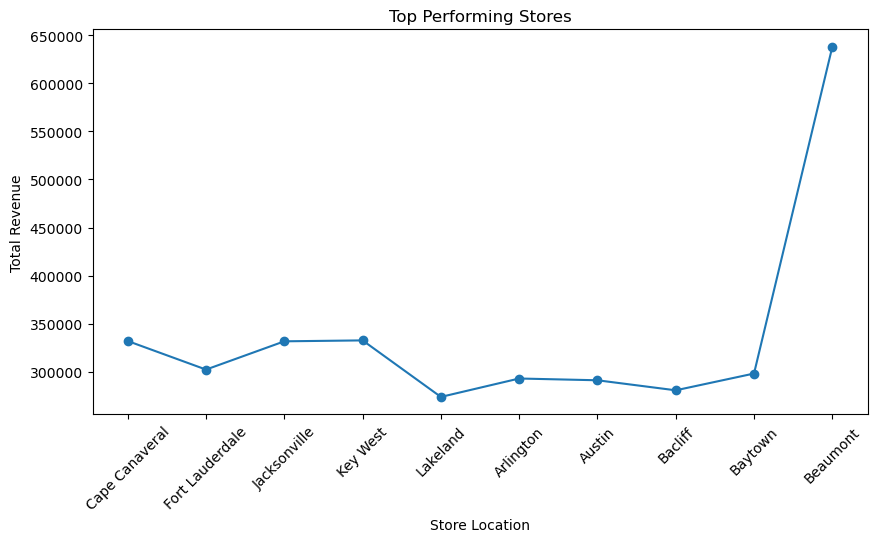

In [56]:
top_store_chart = store_performance.groupby(
    "State"
).head(5)

plt.figure(figsize=(10,5))

plt.plot(
    top_store_chart["Store Location"],
    top_store_chart["Sale Amount"],
    marker="o"
)

plt.xticks(rotation=45)

plt.title("Top Performing Stores")
plt.xlabel("Store Location")
plt.ylabel("Total Revenue")

plt.show()

# Top Customers
The top customers in Florida and Texas by comparing customer IDs with rewards IDs from the data. Flordia customer have a higher sale amount compared to Texas. Can focus promo text to customers with low sale amounts, or who have not came by in a while. 

In [43]:
customer_sales = south_sales.merge(
    customer_list,
    left_on="RewardsID",
    right_on="cust_id",
    how="inner"
)

In [44]:
top_customers = customer_sales.groupby(
    ["State", "cust_id"]
)["Sale Amount"].sum().reset_index()

In [45]:
top_customers = top_customers.sort_values(
    by=["State", "Sale Amount"],
    ascending=[True, False]
)

top_customers

,State,cust_id,Sale Amount
45,Florida,47,4954.99
257,Florida,259,4549.16
188,Florida,190,4415.78
333,Florida,335,3631.94
162,Florida,164,3535.88
...,...,...,...
841,Texas,324,10.25
910,Texas,393,9.95
666,Texas,148,9.09
545,Texas,26,6.85


In [46]:
top_customers.groupby("State").head(5)

,State,cust_id,Sale Amount
45,Florida,47,4954.99
257,Florida,259,4549.16
188,Florida,190,4415.78
333,Florida,335,3631.94
162,Florida,164,3535.88
861,Texas,344,5240.86
990,Texas,474,3479.46
620,Texas,102,3464.91
686,Texas,168,3400.35
788,Texas,271,3127.53


# Product Category Analysis
The number of transactions and total revenue by product category for Florida and Texas. Texas needs to push apparel and merchandise due to Flordia doing well in that category. Flordia needs to improve in the books category. Focus promo on those two categories to help bring sales. 

In [47]:
sales_products = south_sales.merge(
    products,
    on="Prod Num",
    how="inner"
)

In [48]:
sales_products = sales_products.merge(
    product_categories,
    on=["CategoryID", "SubcategoryID"],
    how="inner"
)

In [49]:
category_transactions = sales_products.groupby(
    ["State", "Month", "Category"]
).size().reset_index(name="Transactions")

category_transactions

,State,Month,Category,Transactions
0,Florida,2022-01,Apparel and Merchandise,66
1,Florida,2022-01,Art Supplies,80
2,Florida,2022-01,Books (General),20
3,Florida,2022-01,Stationery and Supplies,69
4,Florida,2022-01,Technology & Accessories,75
...,...,...,...,...
571,Texas,2025-12,Art Supplies,123
572,Texas,2025-12,Books (General),70
573,Texas,2025-12,Stationery and Supplies,170
574,Texas,2025-12,Technology & Accessories,169


In [50]:
category_revenue = sales_products.groupby(
    ["State", "Month", "Category"]
)["Sale Amount"].sum().reset_index()

category_revenue

,State,Month,Category,Sale Amount
0,Florida,2022-01,Apparel and Merchandise,1980.69
1,Florida,2022-01,Art Supplies,2484.65
2,Florida,2022-01,Books (General),553.10
3,Florida,2022-01,Stationery and Supplies,669.58
4,Florida,2022-01,Technology & Accessories,32658.69
...,...,...,...,...
571,Texas,2025-12,Art Supplies,4027.32
572,Texas,2025-12,Books (General),2124.53
573,Texas,2025-12,Stationery and Supplies,1707.14
574,Texas,2025-12,Technology & Accessories,70285.94


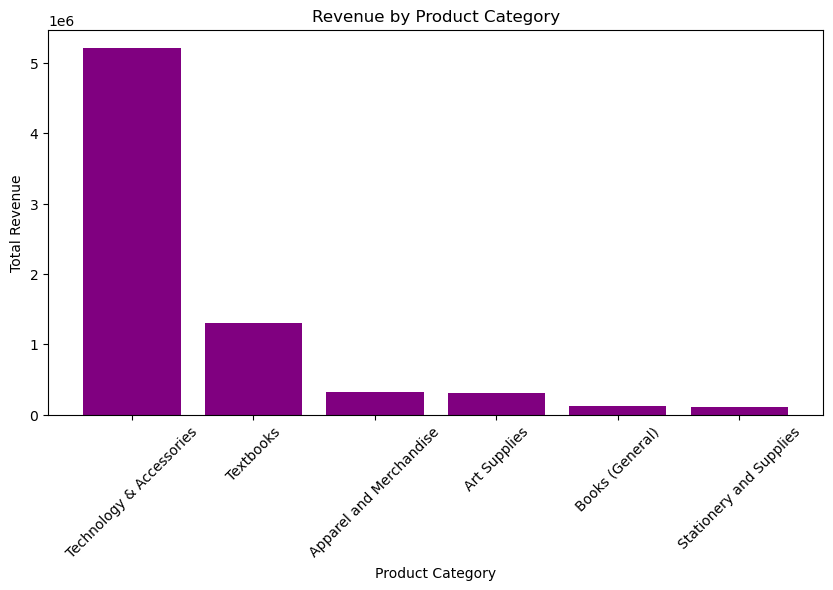

In [57]:
top_categories = sales_products.groupby(
    "Category"
)["Sale Amount"].sum().reset_index()

top_categories = top_categories.sort_values(
    by="Sale Amount",
    ascending=False
)

plt.figure(figsize=(10,5))

plt.bar(
    top_categories["Category"],
    top_categories["Sale Amount"],
    color="purple"
)

plt.xticks(rotation=45)

plt.title("Revenue by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Total Revenue")

plt.show()

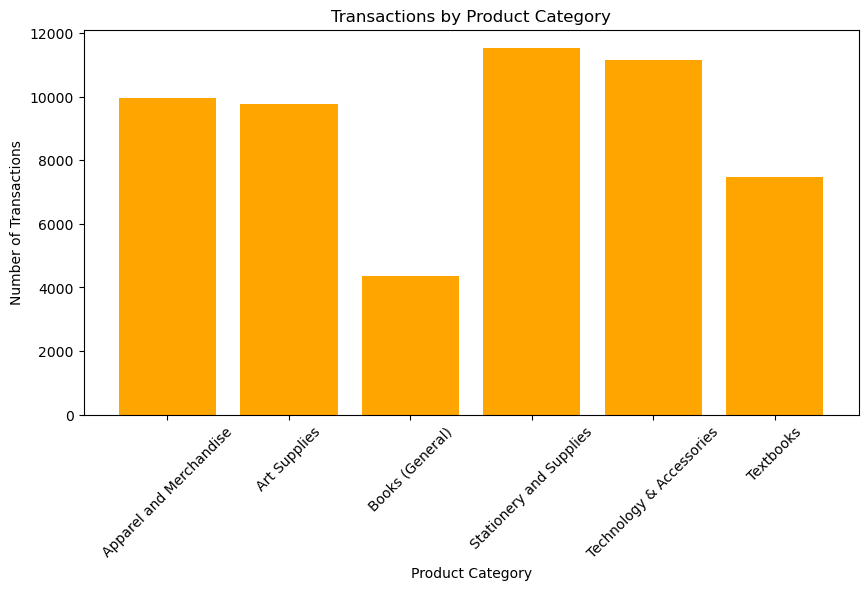

In [58]:
transaction_chart = sales_products.groupby(
    "Category"
).size().reset_index(name="Transactions")

plt.figure(figsize=(10,5))

plt.bar(
    transaction_chart["Category"],
    transaction_chart["Transactions"],
    color="orange"
)

plt.xticks(rotation=45)

plt.title("Transactions by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Number of Transactions")

plt.show()

# Marketing Recommendation

Lower performing categories have the opportunities for growth through discounts, and promotions. They should also focus on offering top customers rewards and marketing texts. Texas will need to focus on adding apparel and merchandise.They can focus promo during the end of the year when nnumbers are slowing down. As for Flordia the textbook and book category. They can offer a sale during back to school months. Or even just offering the sale to loyal members. Doing this may even see changes in the average spent for member customers. 